In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import sqlite3
# import psycopg
# from sqlalchemy import create_engine
df = pd.read_csv("hospital_patient_dataset.csv")



In [2]:

print(df.head())


   patient_id  age  gender       disease     department admission_date  \
0           1   36    Male      Diabetes  Endocrinology     2024-01-26   
1           2   70    Male  Hypertension     Cardiology     2024-04-14   
2           3   12    Male      Fracture    Orthopedics     2024-02-02   
3           4   72    Male        Cancer       Oncology     2025-09-08   
4           5   76  Female      Fracture    Orthopedics     2024-08-13   

  discharge_date  treatment_cost_usd  
0     2024-02-07                7514  
1     2024-04-25               19549  
2     2024-02-03                7823  
3     2025-09-09               18056  
4     2024-08-21                 412  


In [3]:

df['admission_date']= pd.to_datetime(df['admission_date'])
df['discharge_date'] = pd.to_datetime(df['discharge_date'])
df['stay_days']=(df["discharge_date"]-df['admission_date']).dt.days
print(df.head())


   patient_id  age  gender       disease     department admission_date  \
0           1   36    Male      Diabetes  Endocrinology     2024-01-26   
1           2   70    Male  Hypertension     Cardiology     2024-04-14   
2           3   12    Male      Fracture    Orthopedics     2024-02-02   
3           4   72    Male        Cancer       Oncology     2025-09-08   
4           5   76  Female      Fracture    Orthopedics     2024-08-13   

  discharge_date  treatment_cost_usd  stay_days  
0     2024-02-07                7514         12  
1     2024-04-25               19549         11  
2     2024-02-03                7823          1  
3     2025-09-09               18056          1  
4     2024-08-21                 412          8  


month
1     44610329
2     40606148
3     43930465
4     44391229
5     44447646
6     43995608
7     44539714
8     43283523
9     43068614
10    45443867
11    42059560
12    22640174
Name: treatment_cost_usd, dtype: int64


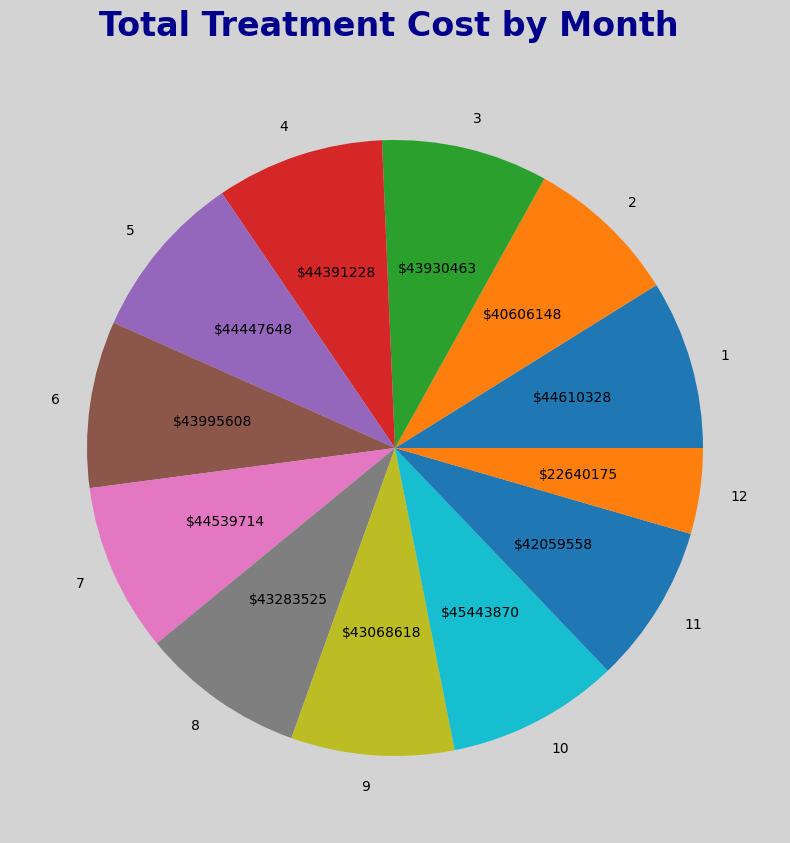

In [87]:
df['month']= df['admission_date'].dt.month


monthGroupe= df.groupby('month')['treatment_cost_usd'].sum()
print(monthGroupe)
plt.figure(figsize=(20,10),facecolor="lightgray")
monthGroupe.plot(kind="pie",autopct=lambda p:f"${int(p*monthGroupe.sum()/100)}" )
plt.title("Total Treatment Cost by Month ",fontsize=24,
    fontweight='bold',
    color='darkblue',
    loc='center', 
    pad=20 )
plt.plot(monthGroupe)
plt.show()
# df.to_excel("h.xlsx", index=False )
# df.to_json("hospital_patients.json", indent=4)



gender
Female    25024
Male      24976
Name: count, dtype: int64


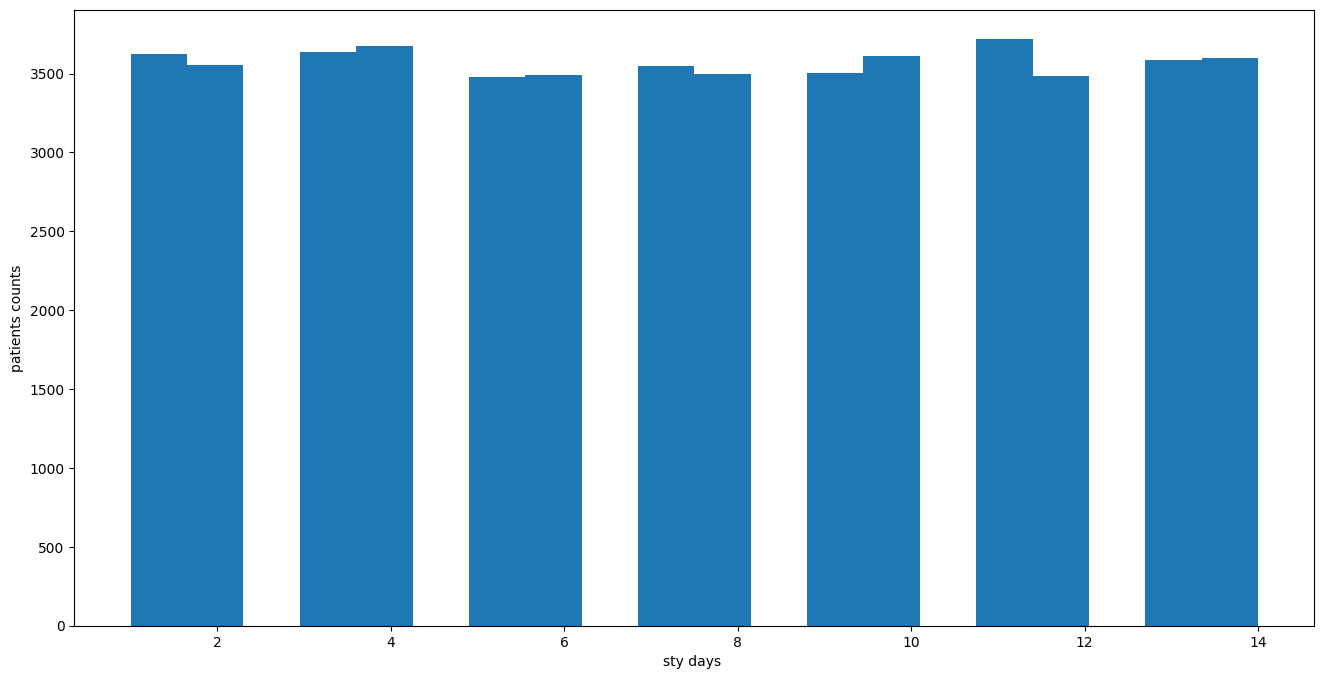

In [88]:
# group by gender 
reveneu_by_gender =df.groupby('gender')['treatment_cost_usd'].sum()
gender =df['gender'].value_counts()
print(gender)
plt.figure(figsize=(16,8))

df['stay_days'].plot(kind="hist",bins=20)
plt.xlabel("sty days ")
plt.ylabel("patients counts")
plt.show()

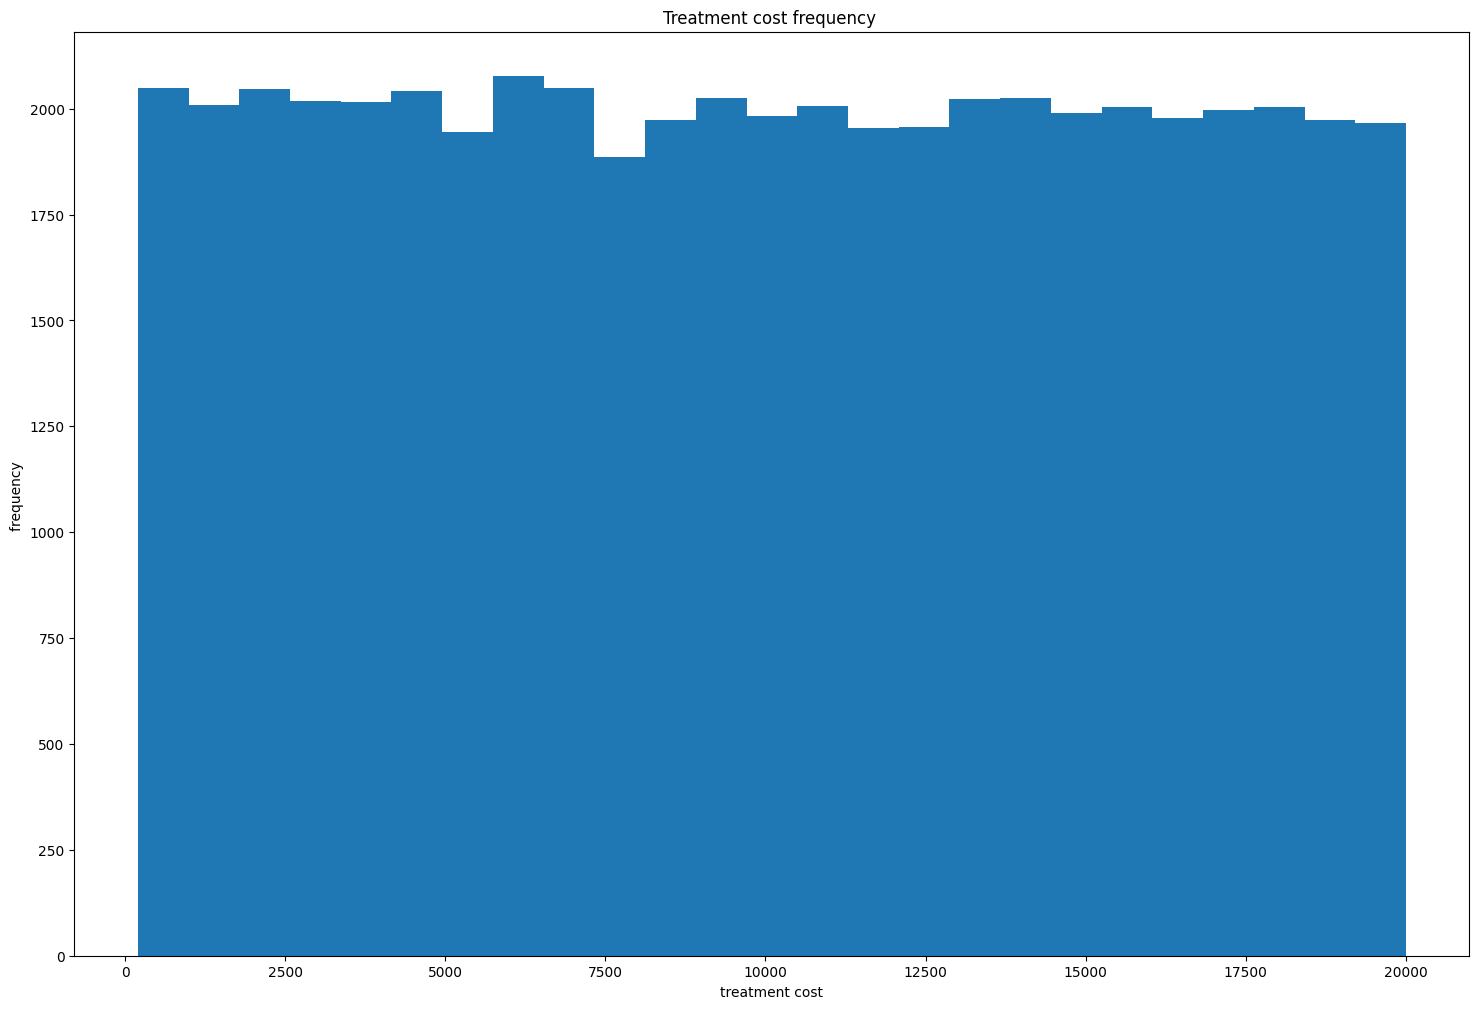

In [89]:
plt.figure(figsize=(18,12))
df["treatment_cost_usd"].plot(kind="hist" ,bins=25)
plt.xlabel("treatment cost")
plt.ylabel("frequency ")
plt.title("Treatment cost frequency ")
plt.show()

department
Cardiology        9895
Endocrinology     4999
Gynecology        4996
Nephrology        4923
Neurology         5171
Oncology          4913
Orthopedics       4957
Pulmonology      10146
Name: patient_id, dtype: int64


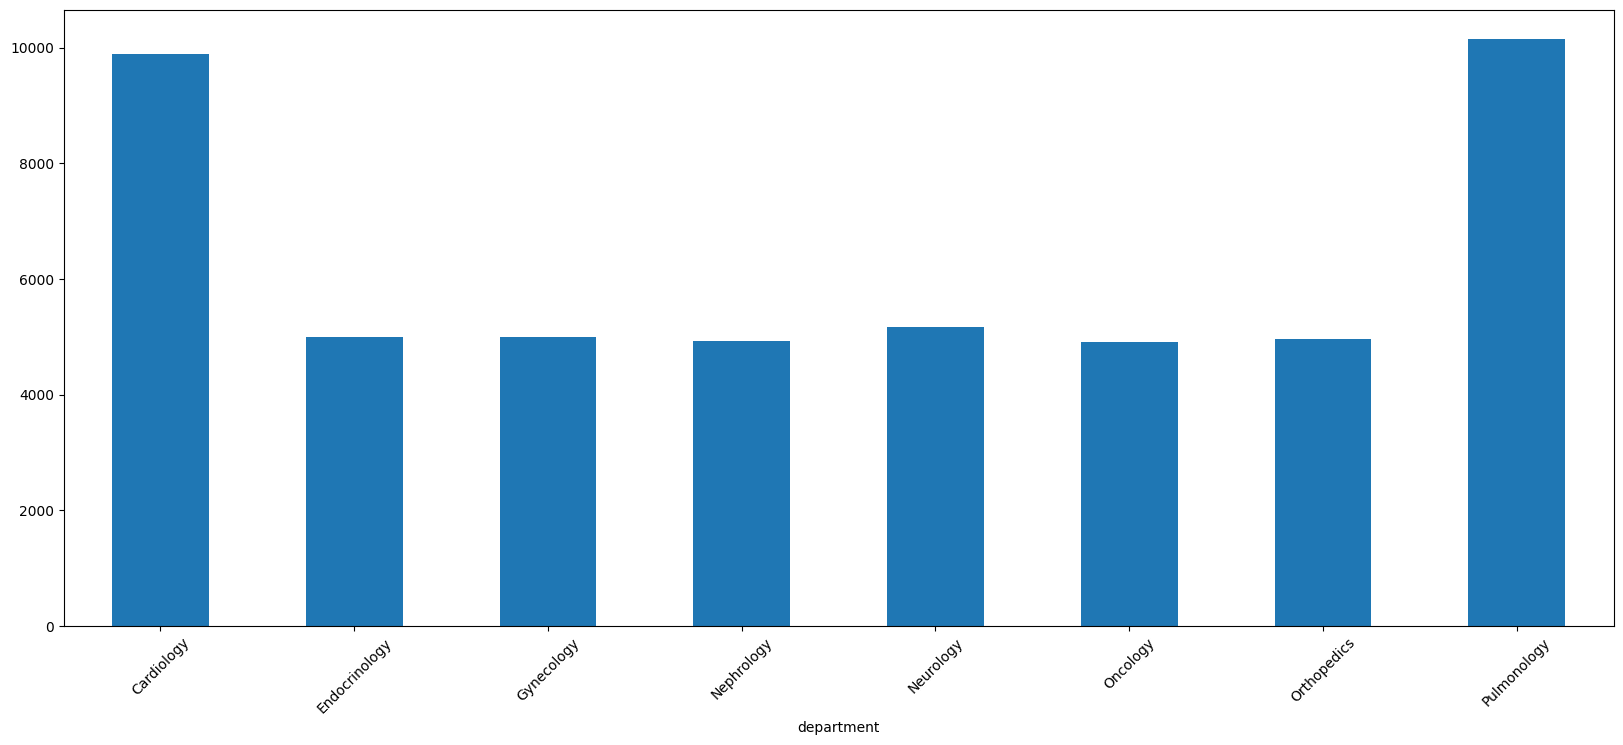

In [90]:
# print(df.head())
department = df.groupby("department")['patient_id'].count()
plt.figure(figsize=(20,8))
print(department)
department.plot(kind='bar')
plt.xticks(rotation=45)
plt.show()

disease
Asthma            5077
Cancer            4913
Diabetes          4999
Fracture          4957
Heart Disease     4927
Hypertension      4968
Kidney Disease    4923
Pneumonia         5069
Pregnancy         4996
Stroke            5171
Name: patient_id, dtype: int64


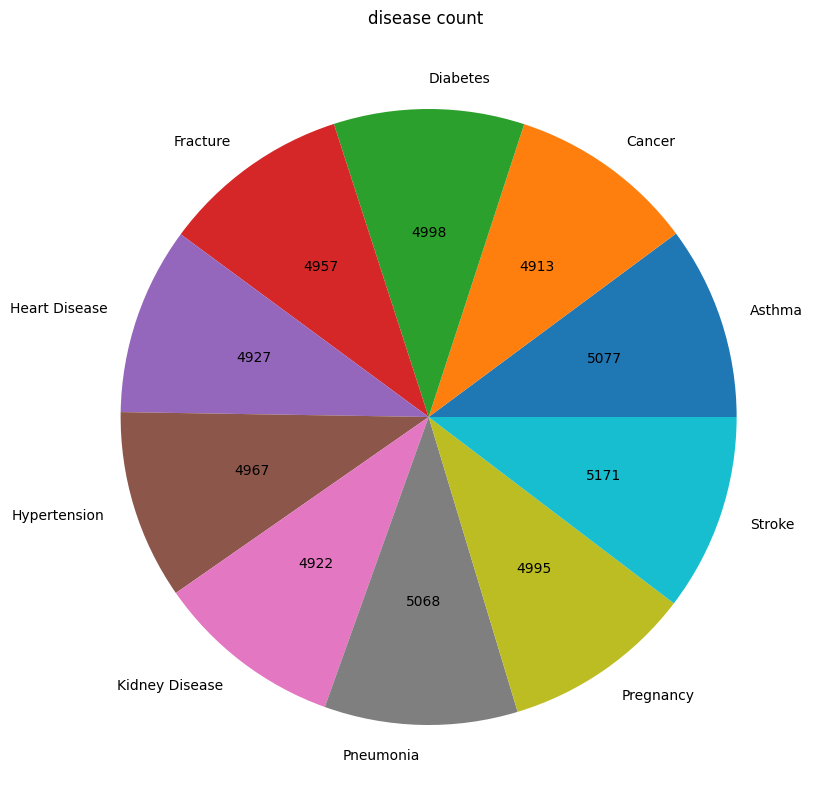

In [91]:

disease= df.groupby('disease')['treatment_cost_usd'].sum()
diseaseCount =df.groupby("disease")['patient_id'].count()
plt.figure(figsize=(20, 10))
print(diseaseCount)
diseaseCount.plot(kind="pie" , autopct=lambda p:f"{int(p*diseaseCount.sum()/100)}")
plt.title("disease count ")
plt.show()


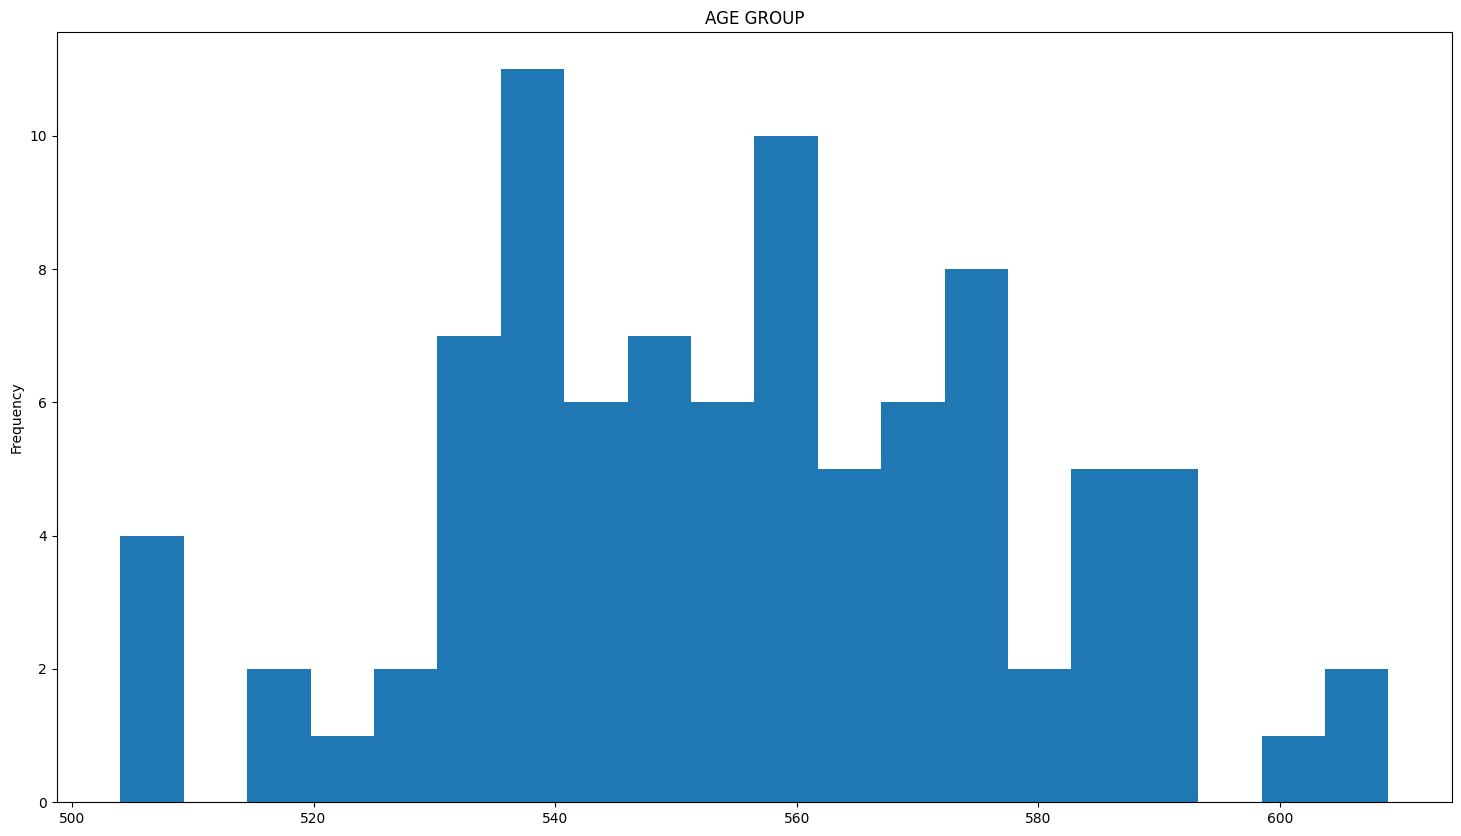

age
1     560
2     608
3     533
4     551
5     566
     ... 
86    504
87    589
88    587
89    528
90    538
Name: patient_id, Length: 90, dtype: int64


In [92]:
df.head()
ageGroupe = df.groupby("age")["patient_id"].count()
plt.figure(figsize=(18,10))
ageGroupe.plot(kind="hist", bins=20)
plt.title("AGE GROUP")
plt.show()
print(ageGroupe)

gender
Female    25024
Male      24976
Name: patient_id, dtype: int64


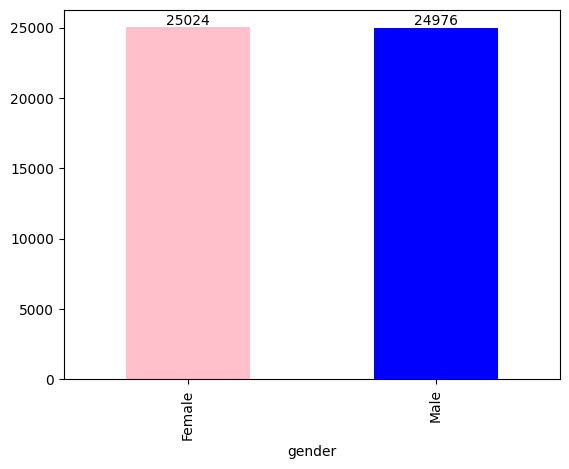

In [93]:

gender_group = df.groupby("gender")['patient_id'].count()
gender_group.to_json("gender_group.json", indent=4)
print(gender_group)
# gender_group.plot(kind="bar", color=[ "pink","blue"])
ax = gender_group.plot(kind="bar", color=["pink", "blue"])

ax.bar_label(ax.containers[0])

plt.show()

In [94]:
df.head()


,patient_id,age,gender,disease,department,admission_date,discharge_date,treatment_cost_usd,stay_days,month
0,1,36,Male,Diabetes,Endocrinology,2024-01-26,2024-02-07,7514,12,1
1,2,70,Male,Hypertension,Cardiology,2024-04-14,2024-04-25,19549,11,4
2,3,12,Male,Fracture,Orthopedics,2024-02-02,2024-02-03,7823,1,2
3,4,72,Male,Cancer,Oncology,2025-09-08,2025-09-09,18056,1,9
4,5,76,Female,Fracture,Orthopedics,2024-08-13,2024-08-21,412,8,8


In [95]:
# gender_group = df.groupby("gender")["patient_id"].count()
# disease_group = df.groupby("disease")["patient_id"].count()

# fig, ax = plt.subplots(1, 2, figsize=(14,6))

# # first plot
# gender_group.plot(kind="bar", ax=ax[0], color=["pink", "blue"])
# ax[0].set_title("Gender Distribution")

# # second plot
# disease_group.plot(kind="bar", ax=ax[1])
# ax[1].set_title("Disease Distribution")

# plt.tight_layout()
# plt.show()